# Seismic Wind Workflow

#### A Tutorial by Simon Ramirez

This notebook details the process for investigating wind speed and direction through seismic analysis, using seismicwind.py

The example seismic file CWA86_example.mseed is required for this tutorial.

## 0. Imports and Setup

In [ ]:
# For Configuration File
import yaml
from pathlib import Path
import importlib
import numpy as np

config_path = ### Enter Config File Path Here

# Load Config File
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Config Variables
name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
aws_path = config['aws_data_path']
seiswind_module = config['seiswind_module']

# obspy GitHub:
# https://github.com/obspy/obspy
from obspy import UTCDateTime as UTC

# seismic-weather GitHub:
# https://github.com/Ramirezs873/seismic-weather
spec = importlib.util.spec_from_file_location("seismicwind", seiswind_module)
seismicwind = importlib.util.module_from_spec(spec)
spec.loader.exec_module(seismicwind)

In [4]:
# Load class Seismic
## Load with config file
seis = seismicwind.Seismic(config=config)

## 1. Load Seismic Data

For a full seismic data and preprocessing tutorial, see Seismic_Data_Tutorial.ipynb

For this workflow, preprocessed seismic data is used. The station is CWA86, which is close to the AWS at Casey Skiway.

The seismic data is from 2022 Dec 25th 11pm to Dec 29th 1am. It has been rotation corrected, demeaned, detrended, and hann windowed. 

In [5]:
# Gather Data
## Station CASY used as an example
data = seis.get_seis(client = None, 
                     network = None, 
                     station = None,
                     location = None, 
                     channel = None,
                     t_start = None,
                     t_end = None,
                     username = None, 
                     password = None,
                     file_name = 'CWA86_example')

Reading existing file: C:\Users\simon\Desktop\UTAS\Honours Research\Workspace\CWA86_example.mseed


## 2. Load AWS Data

For a full aws data tutorial, see AWS_Data_Tutorial.ipynb

In [6]:
aws = data.wind.get_aws(path=aws_path, station_code='300060', id_code='55510926053')

Gather wind data. Timespan must exist within the seismic data timespan.

In [14]:
wind = data.wind.get_var(variable='Wind speed in km/h',
                         year = 2022, 
                         month = 12, 
                         day = (26,28), 
                         hour = None) # None returns all

## 3. Fast Fourier Transform

For further seismic-wind analysis, the Seismic().wind.seismicwind subclass is used.

Apply a FFT to the seismic data using the function spectra_fft().

In [15]:
FFT = data.wind.seismic_wind.spectra_fft(pad_value=np.nan)

## 4. Modelling the Wind from Seismic Power

Using the output of FFT, regression models can be trained and seismic power can be used as a predictor for wind speed and wind direction.

The models available are Ridge, ElasticNet, Support Vector Regression, and Random Forest. These are available through the Models subclass.

Expect high computational times for ElasticNet and Random Forest, especially.

### 4.1 Optimising Models

Each of the models contains a set of parameters which can be optimised for the highest cross validation R^2 value.

In [16]:
data.wind.seismic_wind.models.optimise_ridge(fmin = 1,
                                             fmax = 49,
                                             f_band_width = 1,
                                             step_size = 1,
                                             n_splits = 5,
                                             min_WS = 14) # Threshold Wind Speed for Seismic Detection

WS alpha: 5.857020818056673 CV R²: 0.8860626150165679
--------------------------------------------------
Sin2 alpha: 7.054802310718645 CV R²: -0.015574365669154799
--------------------------------------------------
Cos2 alpha: 1.3219411484660315 CV R²: 0.65512992931678


ElasticNet can take a fair amount of time to run.

In [ ]:
data.wind.seismic_wind.models.optimise_EN(fmin = 1,
                                          fmax = 49,
                                          f_band_width = 1,
                                          step_size = 1,
                                          n_splits = 5,
                                          min_WS = 14) # Threshold Wind Speed for Seismic Detection

In [ ]:
data.wind.seismic_wind.models.optimise_SVR(fmin = 1,
                                           fmax = 49,
                                           f_band_width = 1,
                                           step_size = 1,
                                           n_splits = 5,
                                           min_WS = 14) # Threshold Wind Speed for Seismic Detection

In [ ]:
data.wind.seismic_wind.models.optimise_RF(fmin = 1,
                                          fmax = 49,
                                          f_band_width = 1,
                                          step_size = 1,
                                          n_splits = 5,
                                          min_WS = 14) # Threshold Wind Speed for Seismic Detection

### 4.2 Simple Model Comparison

The models can be compared simply using this function compare_models(). The optimal parameters for each model can be input.

In [17]:
data.wind.seismic_wind.models.compare_models(fmin = 3,
                                             fmax = 49,
                                             f_band_width = 1,
                                             step_size = 1,
                                             n_splits = 5,
                                             min_WS = 14,
                                             n_estimators=100, 
                                             max_depth=15,
                                             min_samples_split=2,
                                             min_samples_leaf=3,
                                             max_features=0.25,
                                             C= 129.15, 
                                             gamma = 0.006, 
                                             epsilon=0.05,
                                             alpha_EN=0.08, 
                                             l1_ratio=0.86, 
                                             alpha_Ridge = 10.24)

Z9.CWA86. WS Cross Validation Results:
Ridge R²: 0.8181 +/- 0.2406
ElasticNet R²: 0.8229 +/- 0.2593
SVR R²: 0.9371 +/- 0.0276
Random Forest R²: 0.9187 +/- 0.0741
----------------------------------------------------------------
Z9.CWA86. Sin2Theta Cross Validation Results:
Ridge R²: 0.0867 +/- 0.7230
ElasticNet R²: -0.1114 +/- 0.1142
SVR R²: 0.1287 +/- 0.3712
Random Forest R²: 0.1903 +/- 0.4984
----------------------------------------------------------------
Z9.CWA86. Cos2Theta Cross Validation Results:
Ridge R²: 0.5474 +/- 0.2243
ElasticNet R²: 0.3853 +/- 0.2335
SVR R²: 0.4741 +/- 0.2670
Random Forest R²: 0.4783 +/- 0.2523


[[{'fmin': 3,
   'fmax': 49,
   'Ridge_var_cv_r2': 0.8181,
   'EN_var_cv_r2': 0.8229,
   'SVR_var_cv_r2': 0.9371,
   'rf_var_cv_r2': 0.9187,
   'Ridge_sin_cv_r2': 0.0867,
   'EN_sin_cv_r2': -0.1114,
   'SVR_sin_cv_r2': 0.1287,
   'rf_sin_cv_r2': 0.1903,
   'Ridge_cos_cv_r2': 0.5474,
   'EN_cos_cv_r2': 0.3853,
   'SVR_cos_cv_r2': 0.4741,
   'rf_cos_cv_r2': 0.4783}]]

### 4.3 Modelling

Parameter inputs for running models will be added soon. At the moment, initial default parameters are being used, but see below for an example model output.

AWS Wind Speed (km/hr) R²: 0.9305
Sin R²: -0.0168
Cos R²: 0.0953
AWS Wind Speed (km/hr) rmse: 5.2858
Sin rmse: 0.0843
Cos rmse: 0.2928
AWS Wind Speed (km/hr) cv R²: 0.7895 +/- 0.3512
Sin cv R²: -1.0170 +/- 0.9542
Cos cv R²: 0.4686 +/- 0.2445
Wind direction Mean Error: 10.53°
Wind direction RMSE: 16.54°
NS: 14.5 Hz, importance = 0.2100
EW: 20.5 Hz, importance = 0.1929
NS: 15.5 Hz, importance = 0.1702
EW: 29.5 Hz, importance = 0.0991
EW: 4.5 Hz, importance = 0.0959
NS: 13.5 Hz, importance = 0.0859
Z: 14.5 Hz, importance = 0.0651
NS: 30.5 Hz, importance = 0.0607
EW: 34.5 Hz, importance = 0.0582
Z: 16.5 Hz, importance = 0.0492


[[{'fmin': 3,
   'fmax': 49,
   'var_r2': 0.930545410174541,
   'sin_r2': -0.0167839670434784,
   'cos_r2': 0.09528751704733918,
   'var_rmse': np.float64(5.285830114561006),
   'sin_rmse': np.float64(0.08432703876523119),
   'cos_rmse': np.float64(0.2927592217573998),
   'y_var_test': array([59.4, 37.1, 76. , 72.4, 18.4, 38.9, 59.4, 77.8, 33.5, 61.2, 68.4,
          40.7, 87.1, 70.2, 40.7, 14.8, 38.9, 40.7, 64.8]),
   'y_sin_test': array([1.        , 0.98480775, 0.98480775, 1.        , 0.93969262,
          1.        , 1.        , 1.        , 0.76604444, 1.        ,
          0.93969262, 0.98480775, 0.93969262, 1.        , 0.76604444,
          0.76604444, 0.8660254 , 1.        , 0.98480775]),
   'y_cos_test': array([ 6.12323400e-17,  1.73648178e-01,  1.73648178e-01,  6.12323400e-17,
          -3.42020143e-01,  6.12323400e-17,  6.12323400e-17,  6.12323400e-17,
           6.42787610e-01,  6.12323400e-17, -3.42020143e-01, -1.73648178e-01,
          -3.42020143e-01,  6.12323400e-17,  6.4

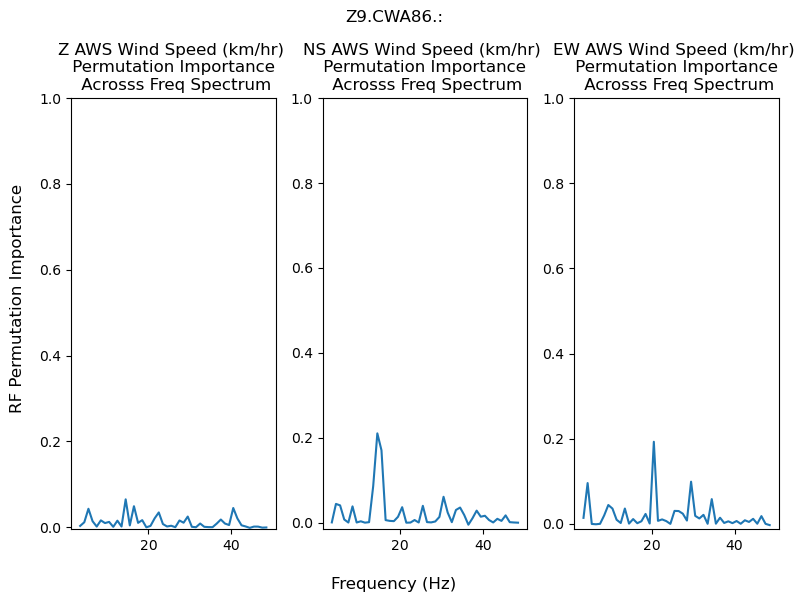

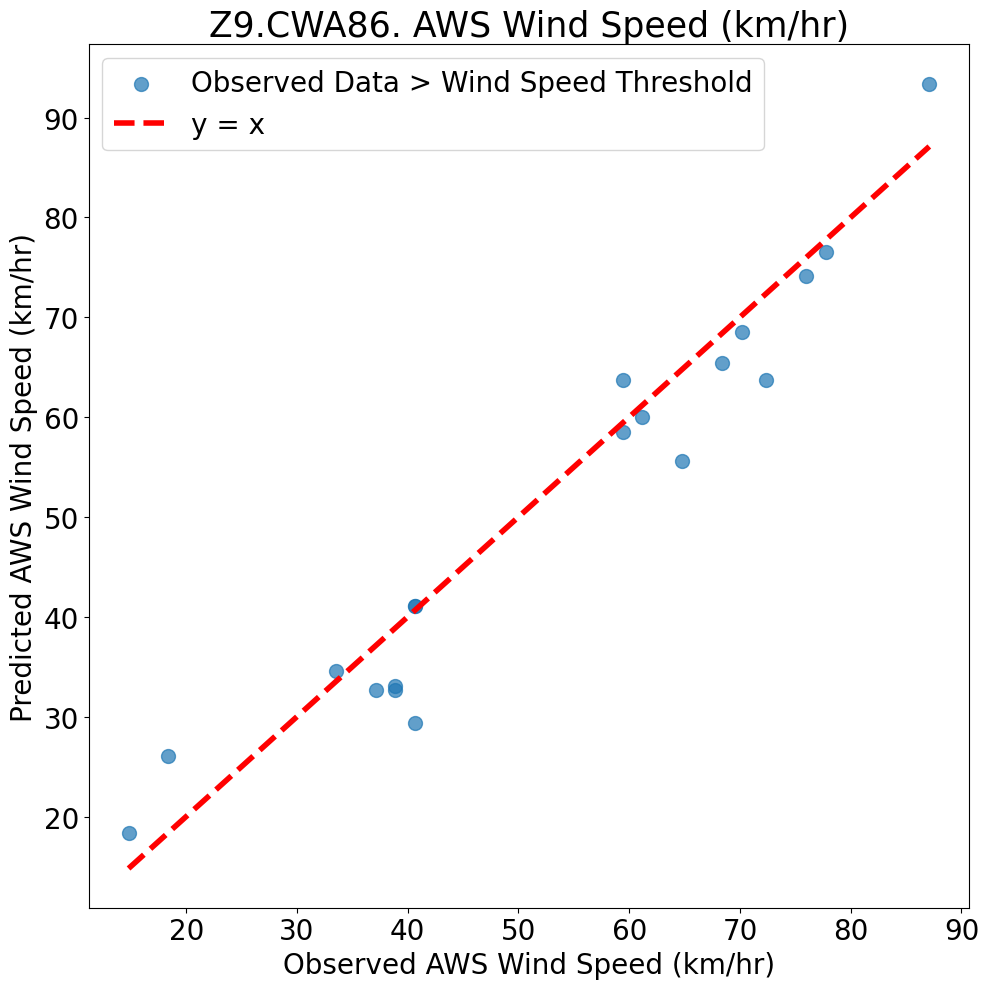

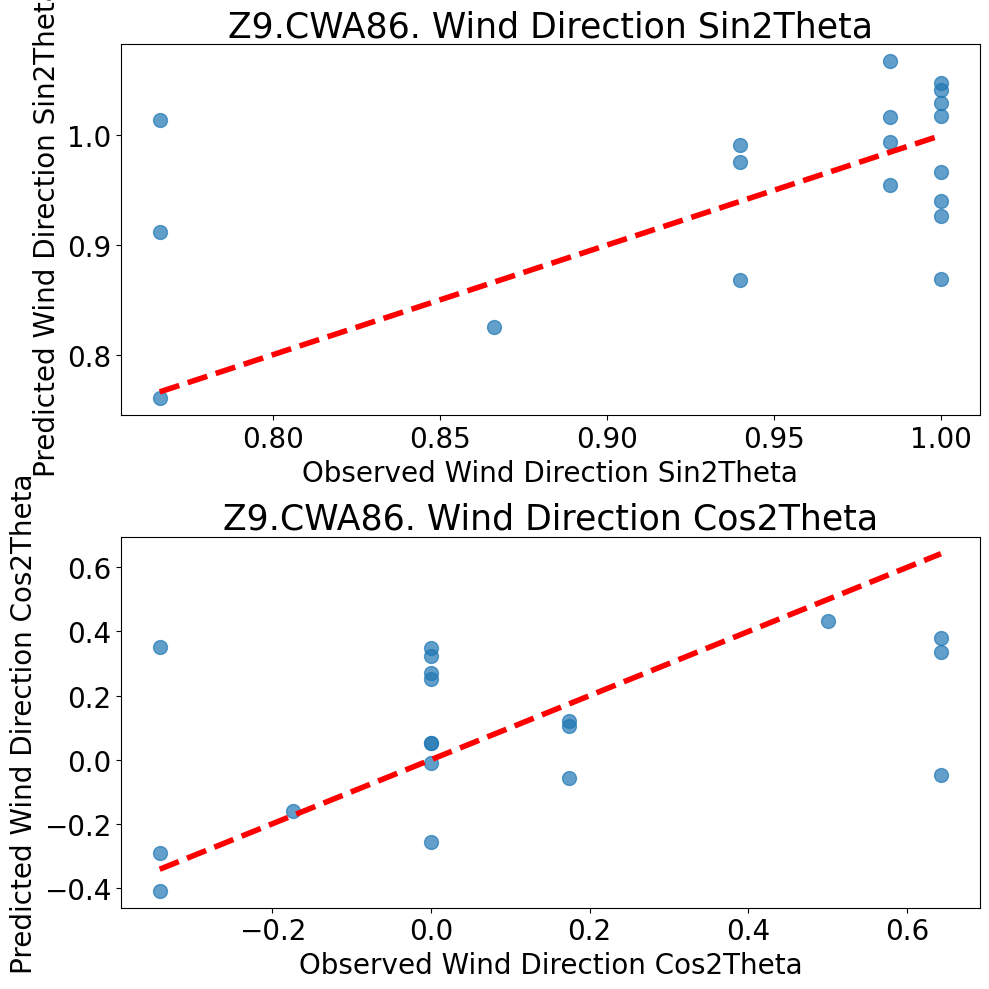

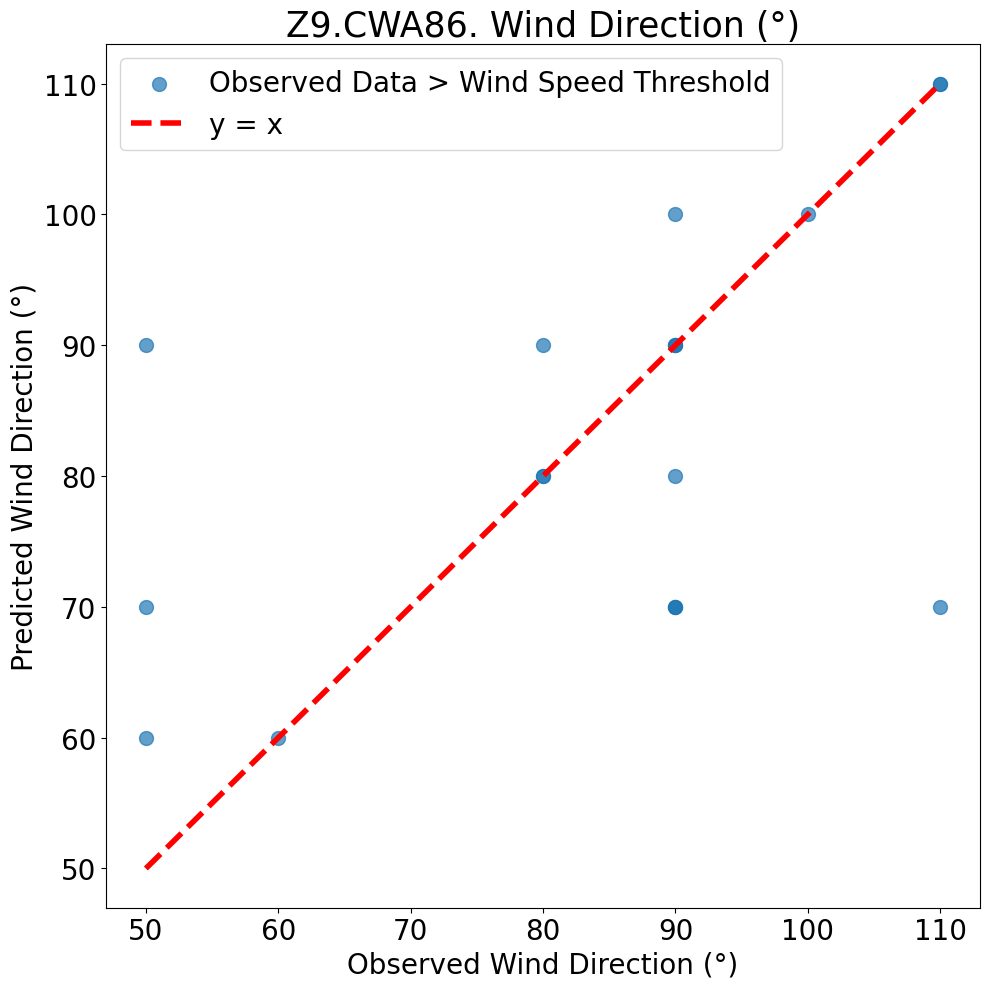

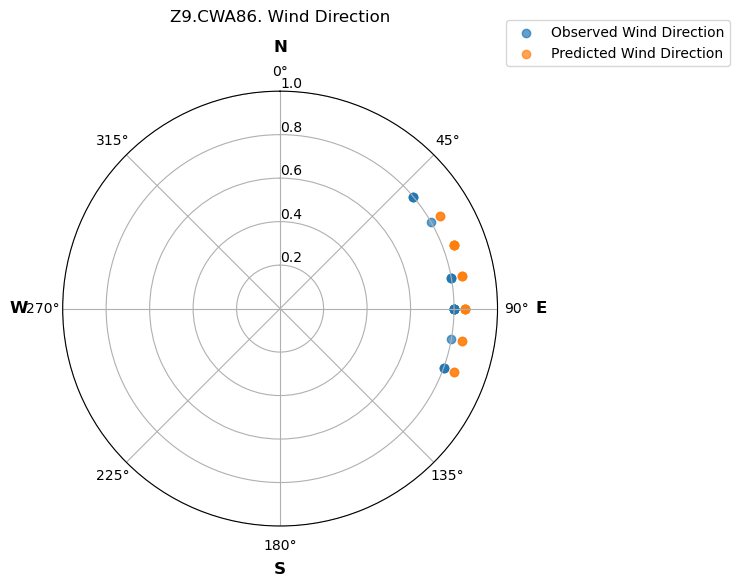

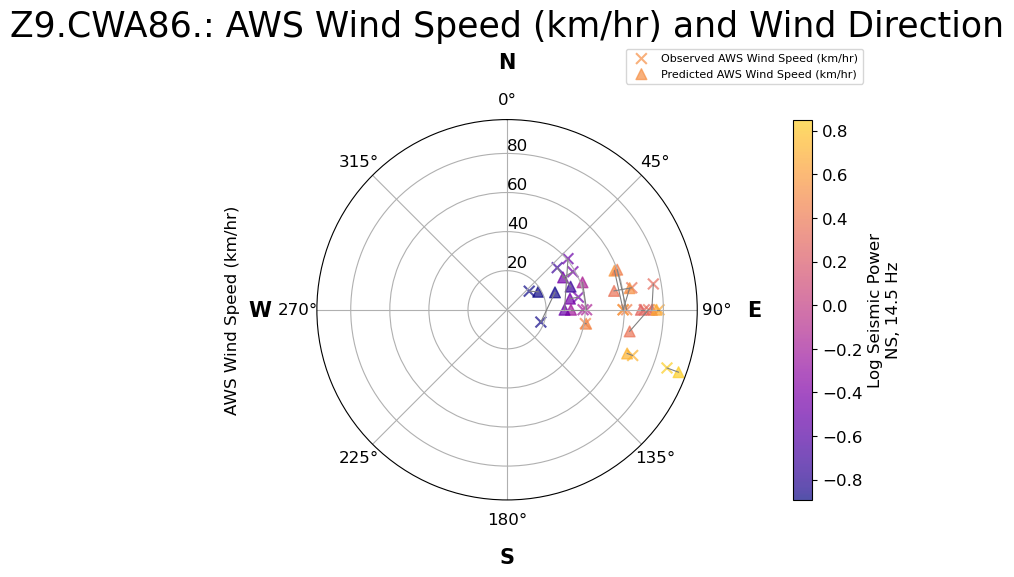

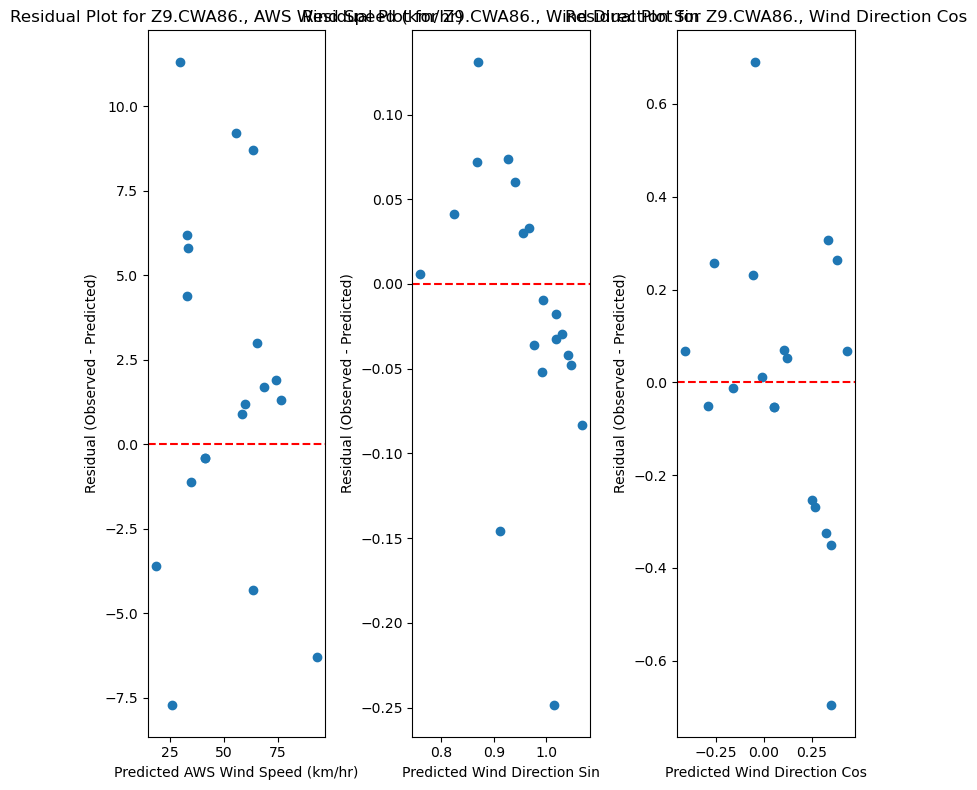

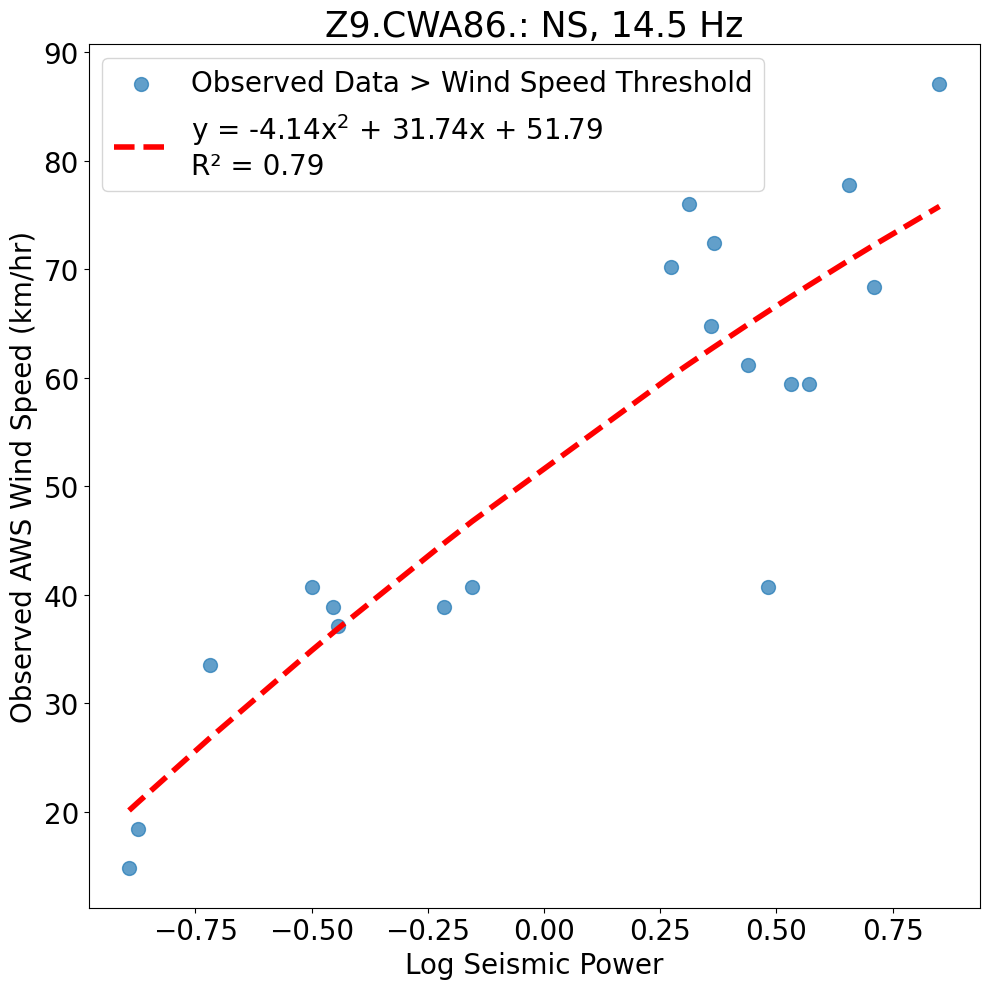

In [21]:
data.wind.seismic_wind.models.Ridge(fmin = 3,
                                    fmax = 49,
                                    f_band_width = 1,
                                    step_size = 1,
                                    n_repeats = 3,
                                    min_WS = 14,
                                    poly_degree = 2,
                                    plot_stat_results = True,
                                    plot_results = True,
                                    plot_residuals = True,
                                    plot_power_aws = True,
                                    variable_name = 'AWS Wind Speed (km/hr)')

In [ ]:
data.wind.seismic_wind.models.EN(fmin = 1,
                                 fmax = 49,
                                 f_band_width = 1,
                                 step_size = 1,
                                 n_repeats = 3,
                                 min_WS = 14,
                                 poly_degree = 2,
                                 plot_stat_results = True,
                                 plot_results = True,
                                 plot_residuals = True,
                                 plot_power_aws = True,
                                 variable_name = 'AWS Wind Speed (km/hr)')

In [ ]:
data.wind.seismic_wind.models.SVR(fmin = 1,
                                 fmax = 49,
                                 f_band_width = 1,
                                 step_size = 1,
                                 n_repeats = 3,
                                 min_WS = 14,
                                 poly_degree = 2,
                                 plot_stat_results = True,
                                 plot_results = True,
                                 plot_residuals = True,
                                 plot_power_aws = True,
                                 variable_name = 'AWS Wind Speed (km/hr)')

In [ ]:
data.wind.seismic_wind.models.RF(fmin = 1,
                                 fmax = 49,
                                 f_band_width = 1,
                                 step_size = 1,
                                 n_repeats = 3,
                                 min_WS = 14,
                                 poly_degree = 2,
                                 plot_stat_results = True,
                                 plot_results = True,
                                 plot_residuals = True,
                                 plot_power_aws = True,
                                 variable_name = 'AWS Wind Speed (km/hr)')